In [73]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import gcol
import string

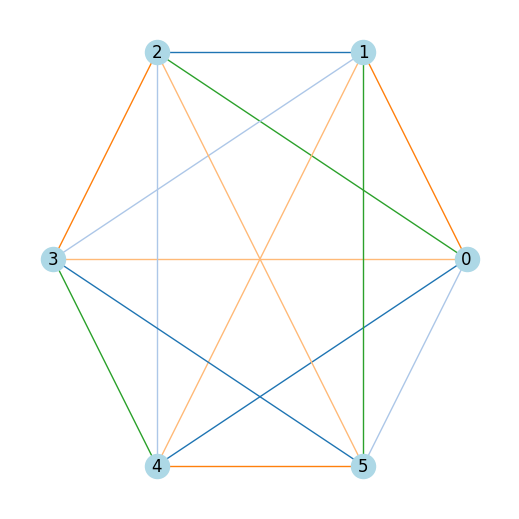

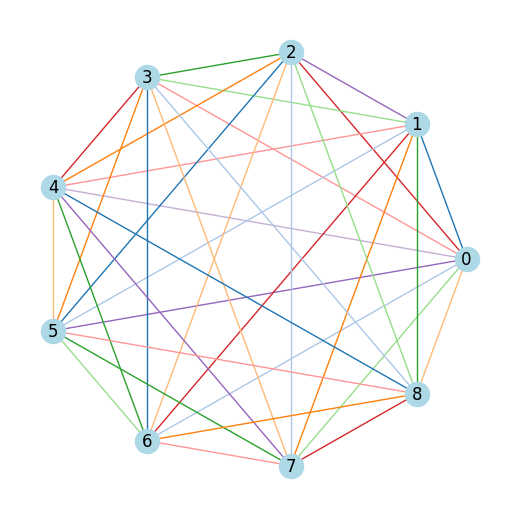

In [85]:
def draw_graph_n(n: int):
    G = nx.complete_graph(n)
    ec = gcol.edge_coloring(G)

    plt.figure(figsize=(5, 5))
    nx.draw(
        G,
        pos=nx.circular_layout(G),
        edge_color=gcol.get_edge_colors(G, ec),
        with_labels=True,
        node_color="lightblue"
    )
    plt.show()
    
draw_graph_n(6)
draw_graph_n(9)

Color num: 5
{(0, 5): 0, (1, 5): 1, (2, 5): 2, (5, 6): 3, (3, 5): 4, (2, 6): 0, (0, 6): 1, (0, 3): 2, (1, 3): 0, (2, 4): 1, (1, 4): 2}


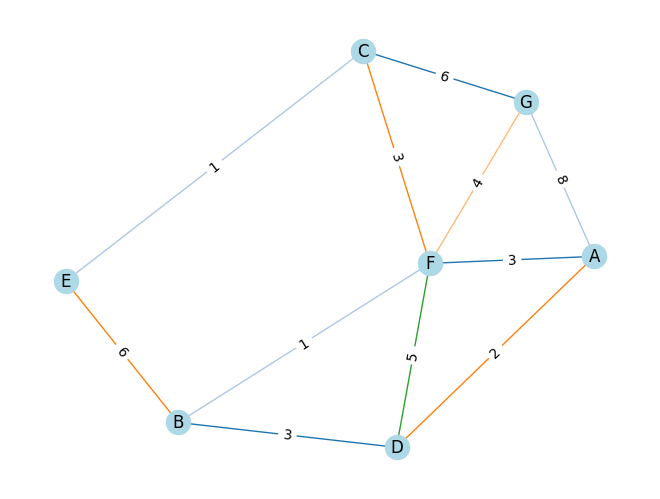

In [75]:
mat = np.array([
    [0, 0, 0, 2, 0, 3, 8],
    [0, 0, 0, 3, 6, 1, 0],
    [0, 0, 0, 0, 1, 3, 6],
    [2, 3, 0, 0, 0, 5, 0],
    [0, 6, 1, 0, 0, 0, 0],
    [3, 1, 3, 5, 0, 0, 4],
    [8, 0, 6, 0, 0, 4, 0]
])

G = nx.from_numpy_array(mat)
letters = string.ascii_uppercase
labels = {i: letters[i] for i in range(len(mat))}
edge_labels = nx.get_edge_attributes(G, "weight")
pos = nx.spring_layout(G, seed=15)
ec = gcol.edge_coloring(G)
# ec[(5, 6)] = 4
color_num = len(set(ec.values()))

nx.draw(G, 
    labels=labels,
    edge_color=gcol.get_edge_colors(G, ec),
    node_color="lightblue",
    pos=pos)
nx.draw_networkx_edge_labels(G, pos=pos, edge_labels=edge_labels)

print(f"Color num: {color_num}")
print(ec)

All paths from  0  to  4 :
[0, 3, 1, 4]: d=11, color_dif=False
[0, 3, 1, 5, 2, 4]: d=9, color_dif=False
[0, 3, 1, 5, 6, 2, 4]: d=16, color_dif=False
[0, 3, 5, 1, 4]: d=14, color_dif=False
[0, 3, 5, 2, 4]: d=10, color_dif=False
[0, 3, 5, 6, 2, 4]: d=18, color_dif=True
[0, 5, 1, 4]: d=10, color_dif=True
[0, 5, 2, 4]: d=7, color_dif=True
[0, 5, 3, 1, 4]: d=11, color_dif=False
[0, 5, 6, 2, 4]: d=13, color_dif=False
[0, 6, 2, 4]: d=15, color_dif=False
[0, 6, 2, 5, 1, 4]: d=18, color_dif=False
[0, 6, 2, 5, 3, 1, 4]: d=25, color_dif=False
[0, 6, 5, 1, 4]: d=13, color_dif=False
[0, 6, 5, 2, 4]: d=16, color_dif=False
[0, 6, 5, 3, 1, 4]: d=26, color_dif=True

The shortest path with color dif:
[0, 5, 2, 4]: d=7


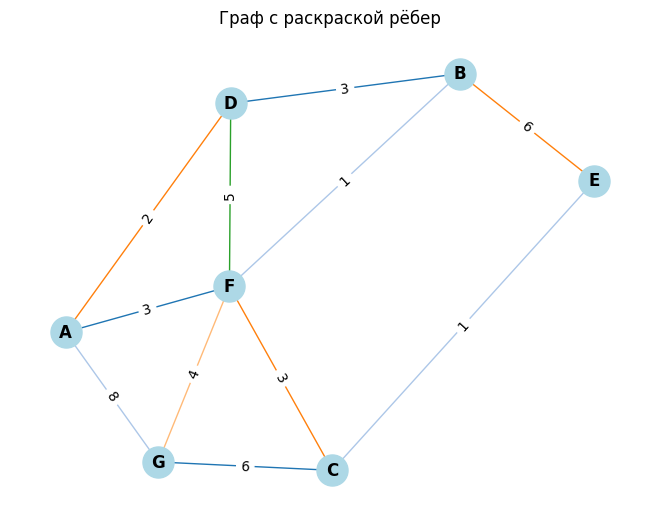

In [81]:
# Приводим ключи ec к единому формату (отсортированная пара)
ec_normalized = {tuple(sorted((u, v))): color for (u, v), color in ec.items()}

# Функция для получения цвета ребра
def get_edge_color(u, v):
    return ec_normalized.get(tuple(sorted((u, v))))

# Поиск всех путей
def find_all_paths(adj, start, end, path=[]):
    path = path + [start]
    if start == end:
        return [path]
    paths = []
    for neighbor, _, _ in adj[start]:
        if neighbor not in path:
            new_paths = find_all_paths(adj, neighbor, end, path)
            for p in new_paths:
                paths.append(p)
    return paths

# Построение списка смежности
n = len(mat)
adj = [[] for _ in range(n)]
for i in range(n):
    for j in range(n):
        if mat[i][j] > 0:
            adj[i].append((j, mat[i][j], get_edge_color(i, j)))

# Поиск всех путей от 0 до 4
start, end = 0, 4
all_paths = find_all_paths(adj, start, end)

# Оценка путей
results = []
for path in all_paths:
    length = 0
    colors = set()
    valid = True
    for i in range(len(path) - 1):
        u, v = path[i], path[i + 1]
        w = mat[u][v]
        color = get_edge_color(u, v)
        if color is None:
            valid = False
            break
        length += w
        if color in colors:
            valid = False
            break
        colors.add(color)
    results.append((path, length, valid))

# Вывод результатов
print("All paths from ", start, " to ", end, ":")
for path, length, valid in results:
    print(f"{path}: d={length}, color_dif={valid}")

valid_paths = [(path, length) for path, length, valid in results if valid]
best_path, best_length = min(valid_paths, key=lambda x: x[1])
print("\nThe shortest path with color dif:")
print(f"{best_path}: d={best_length}")

# Визуализация графа с раскраской рёбер
pos = nx.spring_layout(G, seed=42)

# Подготовка цветов рёбер для рисования (используем нормализованный словарь)
_ec = {tuple(sorted((u, v))): ec_normalized[tuple(sorted((u, v)))] for (u, v) in G.edges()}

# Рисование
nx.draw(G,
        labels=labels,
        edge_color=gcol.get_edge_colors(G, _ec),
        node_color="lightblue",
        pos=pos,
        with_labels=True,
        node_size=500,
        font_weight='bold')

# Подписи весов рёбер
edge_labels = {(u, v): G[u][v]['weight'] for (u, v) in G.edges()}
nx.draw_networkx_edge_labels(G, pos=pos, edge_labels=edge_labels)

plt.title("Граф с раскраской рёбер")
plt.show()

{(0, 3): Text(-0.4942756504963943, 0.16359752840459607, '2'),
 (0, 5): Text(-0.49640162218813366, -0.10941755851393675, '3'),
 (0, 6): Text(-0.6156113201397013, -0.37102451996909896, '8'),
 (1, 3): Text(0.16539312823782215, 0.5492038003374871, '3'),
 (1, 4): Text(0.7742717312153141, 0.4337950056378863, '6'),
 (1, 5): Text(0.16325736267089563, 0.27618019811592265, '1'),
 (2, 4): Text(0.5612282207354661, -0.15762248092166364, '1'),
 (2, 5): Text(-0.0497778944489955, -0.3152312646936675, '3'),
 (2, 6): Text(-0.1689928790137173, -0.5768339252357316, '6'),
 (3, 5): Text(-0.21988905278211646, 0.23189944032192744, '5'),
 (5, 6): Text(-0.34122708685871295, -0.30272157589604326, '4')}

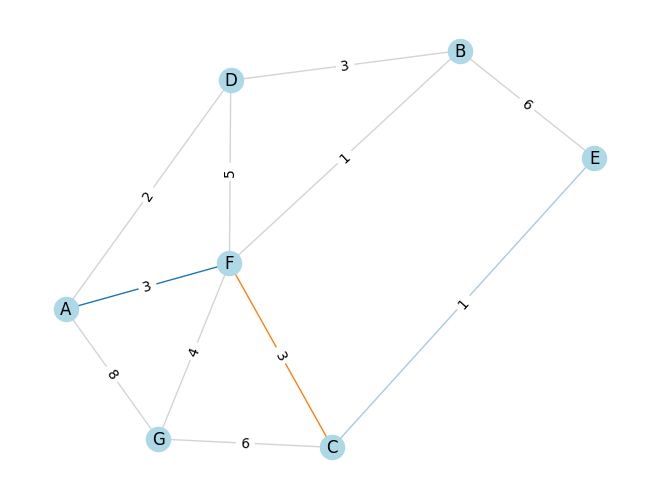

In [83]:
_ec_best_path = {
    tuple(sorted((best_path[i], best_path[i+1]))):
    ec_normalized[tuple(sorted((best_path[i], best_path[i+1])))]
    for i in range(len(best_path) - 1)
}

nx.draw(G, 
    labels=labels,
    edge_color=gcol.get_edge_colors(G, _ec_best_path),
    node_color="lightblue",
    pos=pos)
nx.draw_networkx_edge_labels(G, pos=pos, edge_labels=edge_labels)

Nodes' degrees:
1: 4
2: 4
3: 2
4: 2
5: 5
6: 4
7: 3
8: 3
9: 3
10: 2


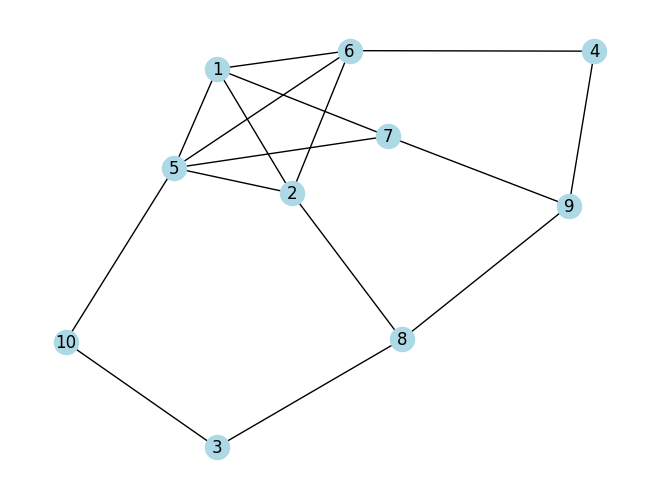

In [68]:
mat = np.array([
     [0, 1, 0, 0, 1, 1, 1, 0, 0, 0],
     [1, 0, 0, 0, 1, 1, 0, 1, 0, 0],
     [0, 0, 0, 0, 0, 0, 0, 1, 0, 1],
     [0, 0, 0, 0, 0, 1, 0, 0, 1, 0],
     [1, 1, 0, 0, 0, 1, 1, 0, 0, 1],
     [1, 1, 0, 1, 1, 0, 0, 0, 0, 0],
     [1, 0, 0, 0, 1, 0, 0, 0, 1, 0],
     [0, 1, 1, 0, 0, 0, 0, 0, 1, 0],
     [0, 0, 0, 1, 0, 0, 1, 1, 0, 0],
     [0, 0, 1, 0, 1, 0, 0, 0, 0, 0]
])

n = len(mat)
G = nx.from_numpy_array(mat)
labels = {i: i+1 for i in range(n)}
pos = nx.spring_layout(G)
nx.draw(G, 
    labels=labels,
    node_color='lightblue',
    pos=pos
)

print("Nodes' degrees:")
for i in range(n):
    print(f"{i+1}: {len(np.nonzero(mat[i])[0])}")

Color num: 4


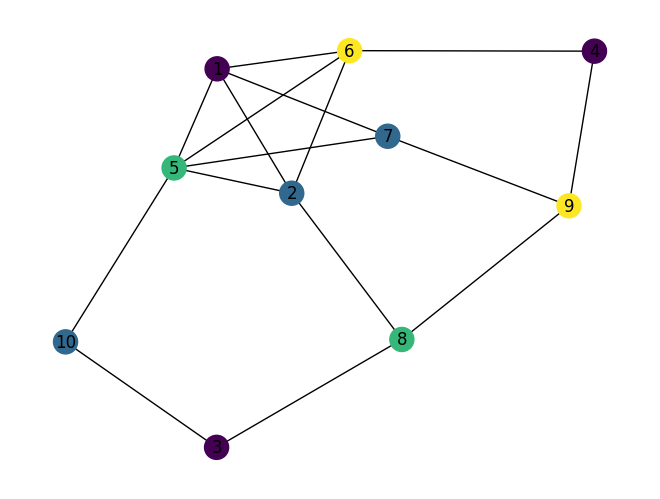

In [69]:
def greedy_coloring(mat):
    n = len(mat)
    colors = [0] * n
    for i in range(n):
        forbidden_colors = set()
        for j in range(len(mat[i])):
            if mat[i][j] != 0 and colors[j] != 0:
                forbidden_colors.add(colors[j])
        for c in range(1, n+1):
            if c not in forbidden_colors:
                colors[i] = c
                break           
    return colors

colors = greedy_coloring(mat)
nx.draw(G, 
    labels=labels,
    node_color=colors,
    pos=pos
)

print(f"Color num: {len(set(colors))}")